### Biodiversity in National Parks

For this project, you will interpret data from the National Parks Service about endangered species in different parks.

In [41]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

observations = pd.read_csv("observations.csv")
species = pd.read_csv("species_info.csv")

print(observations.head())
print(species.head())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic 

In [42]:
print("Observations and species columns")
print(observations.columns)
print(species.columns)

Observations and species columns
Index(['scientific_name', 'park_name', 'observations'], dtype='object')
Index(['category', 'scientific_name', 'common_names', 'conservation_status'], dtype='object')


In [43]:
print("Observations and species information ")
print(observations.info)
print(species.info)

Observations and species information 
<bound method DataFrame.info of                                scientific_name  \
0                           Vicia benghalensis   
1                               Neovison vison   
2                            Prunus subcordata   
3                         Abutilon theophrasti   
4                     Githopsis specularioides   
...                                        ...   
23291                     Croton monanthogynus   
23292                 Otospermophilus beecheyi   
23293  Heterotheca sessiliflora ssp. echioides   
23294                     Dicranella rufescens   
23295                           Cucurbita pepo   

                                 park_name  observations  
0      Great Smoky Mountains National Park            68  
1      Great Smoky Mountains National Park            77  
2                   Yosemite National Park           138  
3                      Bryce National Park            84  
4      Great Smoky Mountains Natio

In [44]:
print("Oberservations and species description")
print(observations.describe())
print(species.describe())

Oberservations and species description
       observations
count  23296.000000
mean     142.287904
std       69.890532
min        9.000000
25%       86.000000
50%      124.000000
75%      195.000000
max      321.000000
              category    scientific_name        common_names  \
count             5824               5824                5824   
unique               7               5541                5504   
top     Vascular Plant  Castor canadensis  Brachythecium Moss   
freq              4470                  3                   7   

       conservation_status  
count                  191  
unique                   4  
top     Species of Concern  
freq                   161  


In [45]:
print("Observations and species null values")
print(observations.isnull().sum())
print(species.isnull().sum())

Observations and species null values
scientific_name    0
park_name          0
observations       0
dtype: int64
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64


In [46]:
print("Observations and species duplicated values")
print(observations.duplicated().sum())
print(species.duplicated().sum())

Observations and species duplicated values
15
0


## Merge the two dataframes to filter the data correctly

In [51]:
biodiversity_dataframe =  pd.merge(observations, species, on="scientific_name")
print(biodiversity_dataframe.head())
print(biodiversity_dataframe["category"].unique())

            scientific_name                            park_name  \
0        Vicia benghalensis  Great Smoky Mountains National Park   
1            Neovison vison  Great Smoky Mountains National Park   
2         Prunus subcordata               Yosemite National Park   
3      Abutilon theophrasti                  Bryce National Park   
4  Githopsis specularioides  Great Smoky Mountains National Park   

   observations        category                        common_names  \
0            68  Vascular Plant  Purple Vetch, Reddish Tufted Vetch   
1            77          Mammal                       American Mink   
2           138  Vascular Plant                        Klamath Plum   
3            84  Vascular Plant                          Velvetleaf   
4            85  Vascular Plant                      Common Bluecup   

  conservation_status  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  
['Vascular Plant' 'M

## How many birds where spotted at each park?

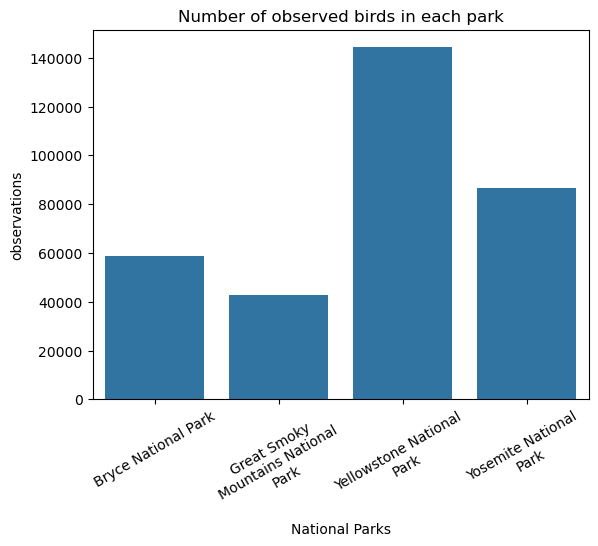

In [52]:
birds = biodiversity_dataframe[biodiversity_dataframe["category"] == "Bird"]
birds_count = birds.groupby("park_name").sum("observations")

#print(birds_count.head())

ax = sns.barplot(data=birds_count, x="park_name", y="observations")
wrapped_labels = [textwrap.fill(label, width=20) for label in birds_count.index]
plt.title("Number of observed birds in each park")
plt.xlabel("National Parks")
ax.set_xticks(range(len(wrapped_labels)))
ax.set_xticklabels(wrapped_labels, rotation=30)
plt.show()

## Which category were spotted the most at each park?

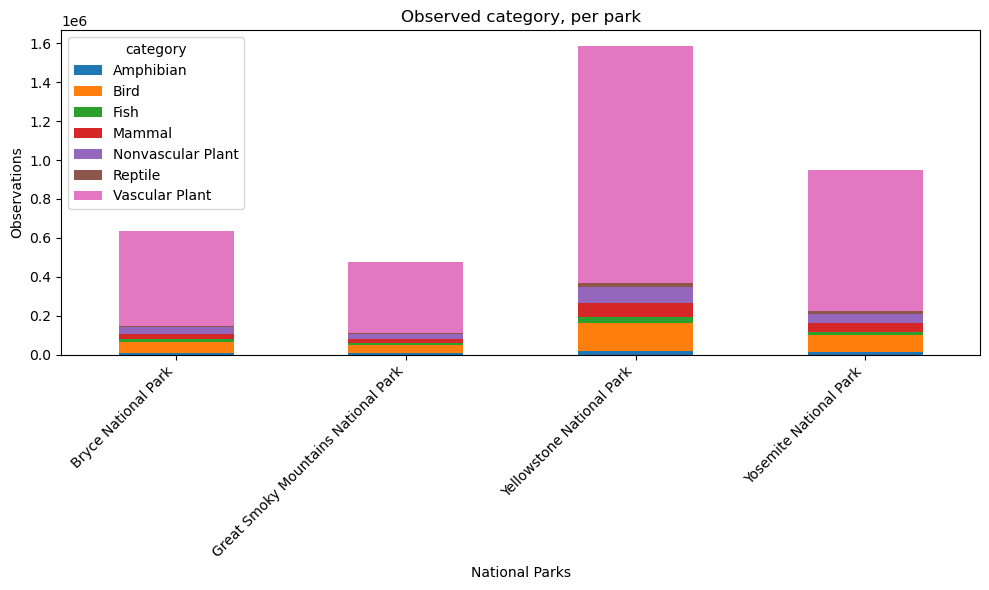

                              park_name           category  observations
0                   Bryce National Park          Amphibian          7542
1                   Bryce National Park               Bird         58590
2                   Bryce National Park               Fish         12823
3                   Bryce National Park             Mammal         28830
4                   Bryce National Park  Nonvascular Plant         32992
5                   Bryce National Park            Reptile          8141
6                   Bryce National Park     Vascular Plant        484373
7   Great Smoky Mountains National Park          Amphibian          5876
8   Great Smoky Mountains National Park               Bird         42869
9   Great Smoky Mountains National Park               Fish          9482
10  Great Smoky Mountains National Park             Mammal         21056
11  Great Smoky Mountains National Park  Nonvascular Plant         24857
12  Great Smoky Mountains National Park            

In [70]:
category_count = (biodiversity_dataframe.groupby(["park_name", "category"])["observations"].sum().reset_index())

# pivot so each category is a column, park_name is the index
pivoted = category_count.pivot(index="park_name", columns="category", values="observations")

ax = pivoted.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_ylabel("Observations")
ax.set_xlabel("National Parks")
plt.title("Observed category, per park")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

df = pd.DataFrame(category_count)
print(df)

The category that was the most spotted in each park was the "Vascular plant" starting from 24857 and going up to 1218162 species.

## What is the distribution of conservation_status for animals?

<bound method NDFrame.describe of                                scientific_name  \
0                           Vicia benghalensis   
1                               Neovison vison   
2                            Prunus subcordata   
3                         Abutilon theophrasti   
4                     Githopsis specularioides   
...                                        ...   
25627                     Croton monanthogynus   
25628                 Otospermophilus beecheyi   
25629  Heterotheca sessiliflora ssp. echioides   
25630                     Dicranella rufescens   
25631                           Cucurbita pepo   

                                 park_name  observations           category  \
0      Great Smoky Mountains National Park            68     Vascular Plant   
1      Great Smoky Mountains National Park            77             Mammal   
2                   Yosemite National Park           138     Vascular Plant   
3                      Bryce National Park       

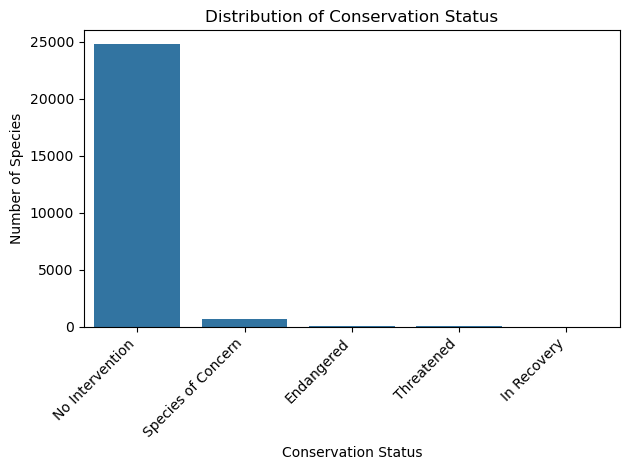

In [78]:
print(biodiversity_dataframe.describe)
biodiversity_dataframe["conservation_status"] = biodiversity_dataframe["conservation_status"].fillna("No Intervention")

conservation_counts = biodiversity_dataframe["conservation_status"].value_counts()
print(conservation_counts)

ax = sns.barplot(x=conservation_counts.index, y=conservation_counts.values)
plt.title("Distribution of Conservation Status")
plt.xlabel("Conservation Status")
plt.ylabel("Number of Species")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Are certain types of species more likely to be endangered?

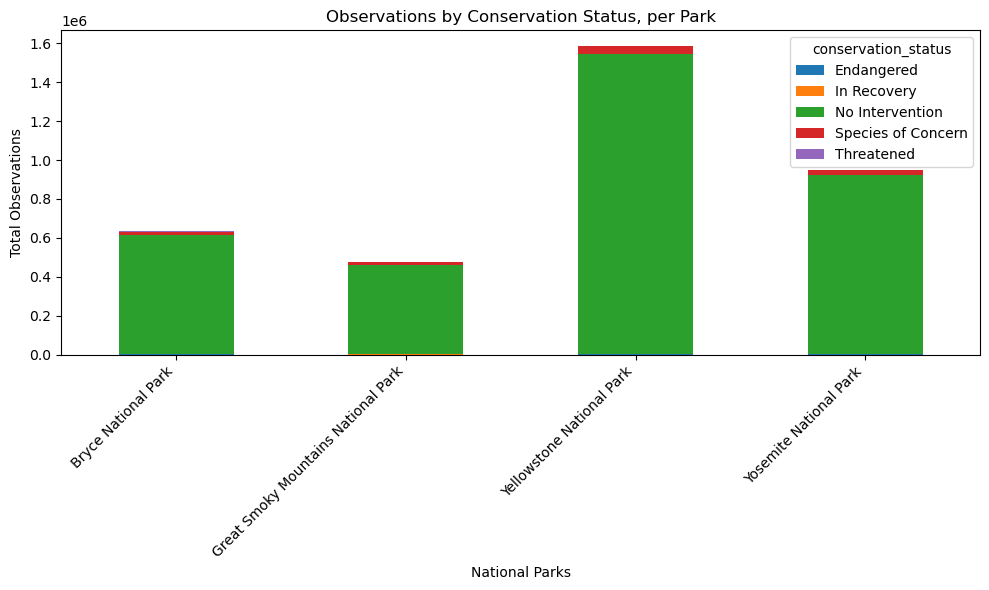

conservation_status                  Endangered  In Recovery  No Intervention  \
park_name                                                                       
Bryce National Park                         619          388           614682   
Great Smoky Mountains National Park         393          248           462047   
Yellowstone National Park                  1558          889          1543058   
Yosemite National Park                      943          582           922539   

conservation_status                  Species of Concern  Threatened  
park_name                                                            
Bryce National Park                               17011         591  
Great Smoky Mountains National Park               11735         440  
Yellowstone National Park                         40677        1459  
Yosemite National Park                            24539         849  


In [87]:
status_obs = (
    biodiversity_dataframe
    .groupby(["park_name", "conservation_status"])["observations"]
    .sum()
    .reset_index()
)

status_pivot = status_obs.pivot(index="park_name", columns="conservation_status", values="observations")

ax = status_pivot.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_ylabel("Total Observations")
ax.set_xlabel("National Parks")
plt.title("Observations by Conservation Status, per Park")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

df_conservation_park = pd.DataFrame(status_pivot)
print(df_conservation_park)

There are more species in each park that do not requires intervention,